In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('wine.csv',usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic acid']

In [5]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

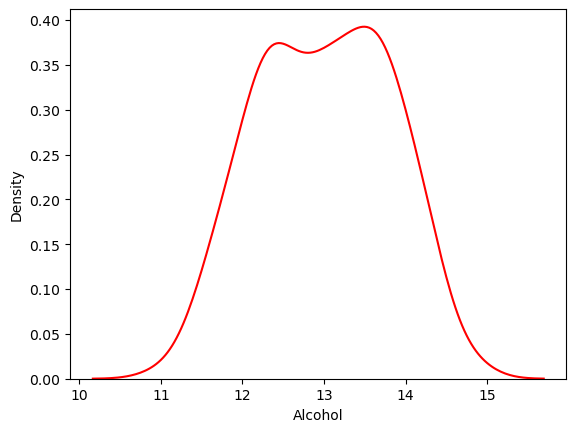

In [7]:
sns.kdeplot(df['Alcohol'], fill=False, color='r', label='Alcohol')


<Axes: xlabel='Malic acid', ylabel='Density'>

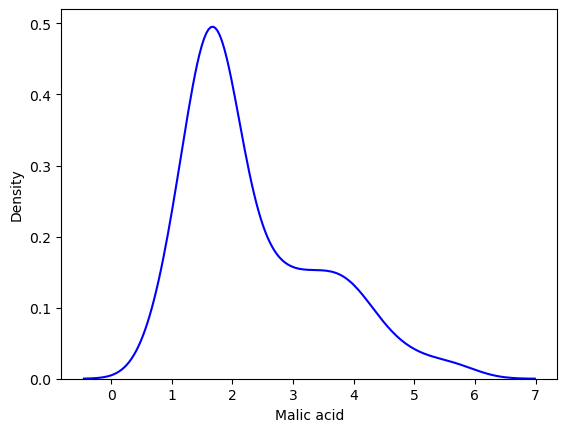

In [8]:
sns.kdeplot(df['Malic acid'], fill=False, color='b', label='Malic acid')

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

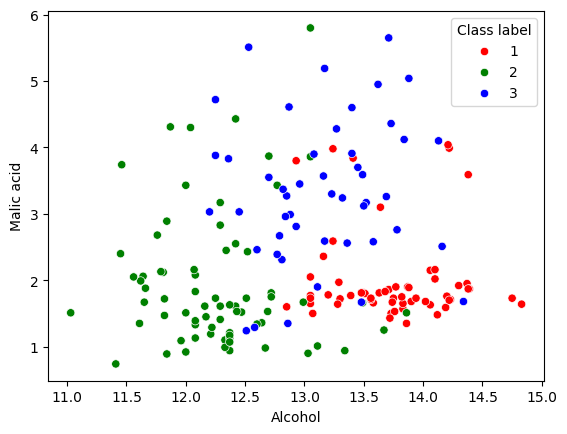

In [10]:
color_dict={1:'red',2:'green',3:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label',axis=1),df['Class label'],test_size=0.3,random_state=42)

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [15]:
np.round(X_train_scaled.describe(),2)

,Alcohol,Malic acid
count,124.00,124.00
mean,0.51,0.31
std,0.22,0.22
min,0.00,0.00
25%,0.33,0.15
50%,0.50,0.21
75%,0.70,0.46
max,1.00,1.00


<Axes: title={'center': 'After Scaling'}, xlabel='Alcohol', ylabel='Density'>

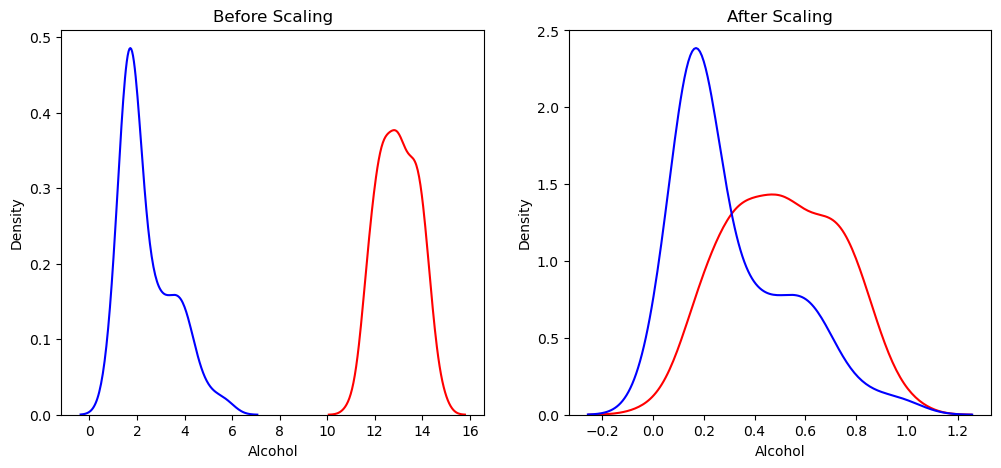

In [16]:
fig , (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], fill=False, color='r', label='Alcohol', ax=ax1)
sns.kdeplot(X_train['Malic acid'], fill=False, color='b', label='Malic acid', ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], fill=False, color='r', label='Alcohol', ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], fill=False, color='b', label='Malic acid', ax=ax2)